In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style="darkgrid")

print("✅ Libraries loaded")

✅ Libraries loaded


In [13]:
# Load cleaned hourly dataset
df = pd.read_csv('../data/cleaned_hourly.csv', parse_dates=['datetime'], index_col='datetime')

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (34589, 7)
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00
Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [14]:
def create_features(df):
    df = df.copy()
    
    # Use only Global_active_power as base
    # Drop directly correlated electrical columns
    df = df[['Global_active_power']].copy()

    # ⏰ Time-based features
    df['hour']        = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['month']       = df.index.month
    df['quarter']     = df.index.quarter
    df['year']        = df.index.year
    df['day_of_year'] = df.index.dayofyear
    df['week']        = df.index.isocalendar().week.astype(int)

    # 📅 Calendar features
    df['is_weekend']  = (df.index.dayofweek >= 5).astype(int)
    df['is_night']    = ((df.index.hour >= 22) | (df.index.hour <= 6)).astype(int)
    df['is_peak']     = ((df.index.hour >= 6) & (df.index.hour <= 9) |
                         (df.index.hour >= 17) & (df.index.hour <= 21)).astype(int)

    # 🌦️ Season feature
    df['season'] = df['month'].map({
        12: 1, 1: 1, 2: 1,
        3: 2,  4: 2, 5: 2,
        6: 3,  7: 3, 8: 3,
        9: 4, 10: 4, 11: 4
    })

    # 📉 Lag features
    df['lag_1h']   = df['Global_active_power'].shift(1)
    df['lag_2h']   = df['Global_active_power'].shift(2)
    df['lag_3h']   = df['Global_active_power'].shift(3)
    df['lag_24h']  = df['Global_active_power'].shift(24)
    df['lag_48h']  = df['Global_active_power'].shift(48)
    df['lag_168h'] = df['Global_active_power'].shift(168)

    # 📊 Rolling window features
    df['rolling_mean_3h']  = df['Global_active_power'].shift(1).rolling(window=3).mean()
    df['rolling_mean_24h'] = df['Global_active_power'].shift(1).rolling(window=24).mean()
    df['rolling_mean_7d']  = df['Global_active_power'].shift(1).rolling(window=168).mean()
    df['rolling_std_24h']  = df['Global_active_power'].shift(1).rolling(window=24).std()

    return df

df_feat = create_features(df)
df_feat.dropna(inplace=True)

print(f"✅ Features created — no leakage!")
print(f"Shape: {df_feat.shape}")
print(f"Features: {list(df_feat.columns)}")

✅ Features created — no leakage!
Shape: (34421, 22)
Features: ['Global_active_power', 'hour', 'day_of_week', 'month', 'quarter', 'year', 'day_of_year', 'week', 'is_weekend', 'is_night', 'is_peak', 'season', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_3h', 'rolling_mean_24h', 'rolling_mean_7d', 'rolling_std_24h']


In [15]:
# Define target and features
TARGET = 'Global_active_power'
FEATURES = [col for col in df_feat.columns if col != TARGET]

X = df_feat[FEATURES]
y = df_feat[TARGET]

# Split by time — last 20% as test (never shuffle time series data!)
split_idx = int(len(df_feat) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"✅ Train/Test Split Done!")
print(f"Training set : {X_train.shape} | {y_train.index.min()} → {y_train.index.max()}")
print(f"Testing set  : {X_test.shape}  | {y_test.index.min()} → {y_test.index.max()}")
print(f"Train size   : {len(X_train):,} rows ({80}%)")
print(f"Test size    : {len(X_test):,} rows ({20}%)")

✅ Train/Test Split Done!
Training set : (27536, 21) | 2006-12-23 17:00:00 → 2010-02-13 00:00:00
Testing set  : (6885, 21)  | 2010-02-13 01:00:00 → 2010-11-26 21:00:00
Train size   : 27,536 rows (80%)
Test size    : 6,885 rows (20%)


In [16]:
# Define target and features
TARGET = 'Global_active_power'
FEATURES = [col for col in df_feat.columns if col != TARGET]

X = df_feat[FEATURES]
y = df_feat[TARGET]

# Split by time — last 20% as test (never shuffle time series data!)
split_idx = int(len(df_feat) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"✅ Train/Test Split Done!")
print(f"Training set : {X_train.shape} | {y_train.index.min()} → {y_train.index.max()}")
print(f"Testing set  : {X_test.shape}  | {y_test.index.min()} → {y_test.index.max()}")
print(f"Train size   : {len(X_train):,} rows ({80}%)")
print(f"Test size    : {len(X_test):,} rows ({20}%)")

✅ Train/Test Split Done!
Training set : (27536, 21) | 2006-12-23 17:00:00 → 2010-02-13 00:00:00
Testing set  : (6885, 21)  | 2010-02-13 01:00:00 → 2010-11-26 21:00:00
Train size   : 27,536 rows (80%)
Test size    : 6,885 rows (20%)


In [17]:
# Train Random Forest model
print("⏳ Training Random Forest model...")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("✅ Model trained successfully!")

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate model
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n📊 Model Performance on Test Set:")
print(f"{'='*40}")
print(f"MAE  (Mean Absolute Error)  : {mae:.4f} kW")
print(f"RMSE (Root Mean Sq. Error)  : {rmse:.4f} kW")
print(f"R²   (R-Squared Score)      : {r2:.4f}")
print(f"MAPE (Mean Abs % Error)     : {mape:.2f}%")
print(f"{'='*40}")

⏳ Training Random Forest model...
✅ Model trained successfully!

📊 Model Performance on Test Set:
MAE  (Mean Absolute Error)  : 0.3236 kW
RMSE (Root Mean Sq. Error)  : 0.4723 kW
R²   (R-Squared Score)      : 0.5821
MAPE (Mean Abs % Error)     : 43.69%


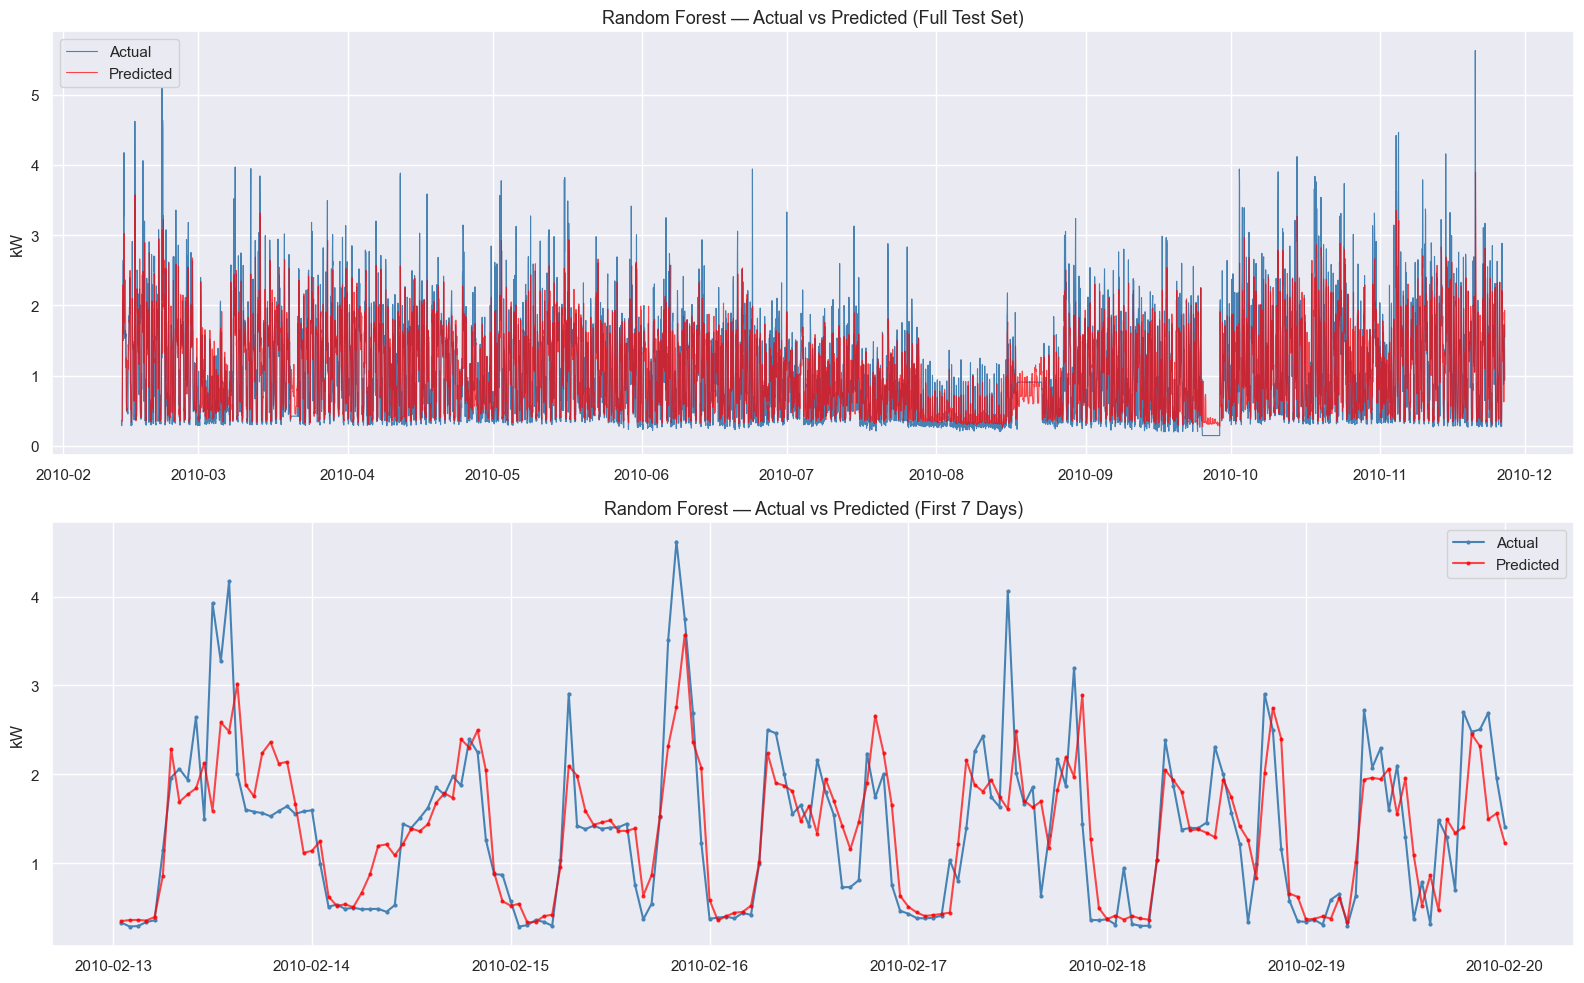

In [18]:
# Plot predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1 — Full test set
axes[0].plot(y_test.index, y_test.values, color='steelblue', 
             linewidth=0.8, label='Actual')
axes[0].plot(y_test.index, y_pred, color='red', 
             linewidth=0.8, label='Predicted', alpha=0.7)
axes[0].set_title('Random Forest — Actual vs Predicted (Full Test Set)', fontsize=13)
axes[0].set_ylabel('kW')
axes[0].legend()

# Plot 2 — Zoom into first 7 days of test set
axes[1].plot(y_test.index[:168], y_test.values[:168], color='steelblue',
             linewidth=1.5, label='Actual', marker='o', markersize=2)
axes[1].plot(y_test.index[:168], y_pred[:168], color='red',
             linewidth=1.5, label='Predicted', marker='o', markersize=2, alpha=0.7)
axes[1].set_title('Random Forest — Actual vs Predicted (First 7 Days)', fontsize=13)
axes[1].set_ylabel('kW')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/rf_predictions.png', dpi=150)
plt.show()

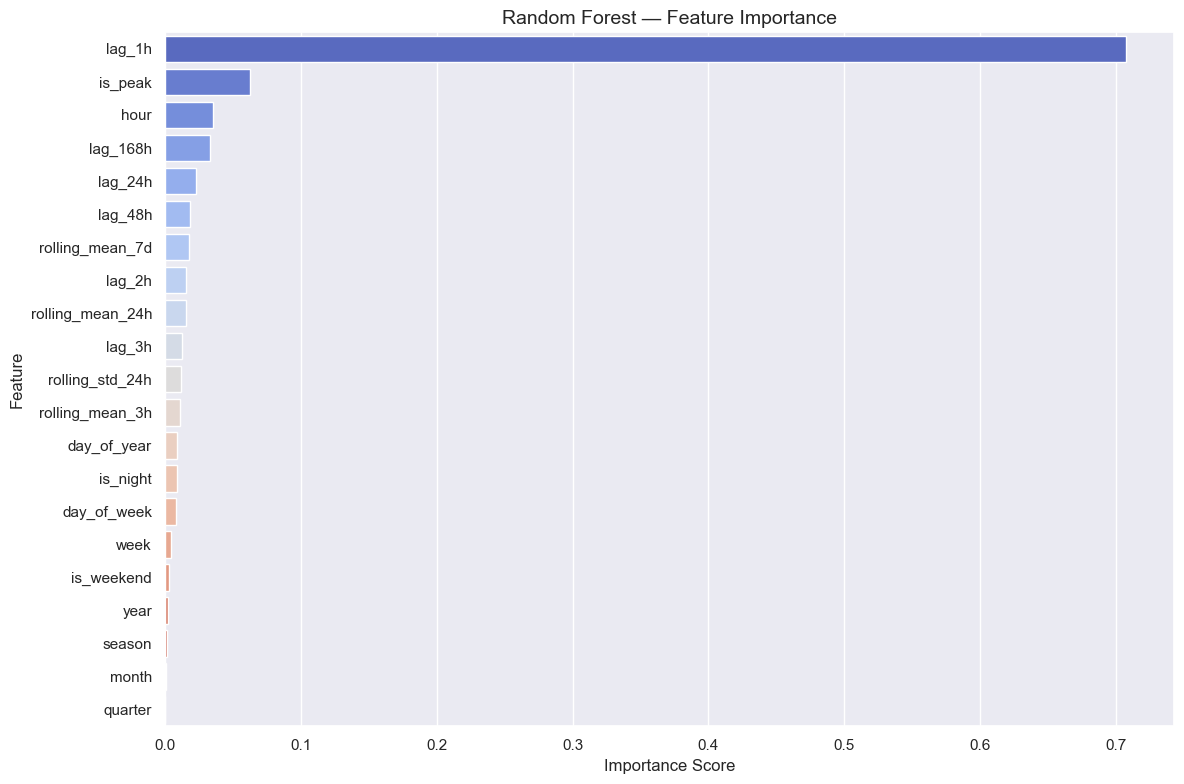


🏆 Top 5 Most Important Features:
     Feature  Importance
11    lag_1h    0.707482
9    is_peak    0.062169
0       hour    0.035325
16  lag_168h    0.033297
14   lag_24h    0.022779


In [19]:
# Feature Importance Plot
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='coolwarm')
plt.title('Random Forest — Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("\n🏆 Top 5 Most Important Features:")
print(importance_df.head())

In [21]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.2 MB/s eta 0:01:24
   ---------------------------------------- 0.5/101.7 MB 1.2 MB/s eta 0:01:24
   ---------------------------------------- 0.8/101.7 MB 887.5 kB/s eta 0:01:54
   ---------------------------------------- 1.0/101.7 MB 972.9 kB/s eta 0:01:44
    --------------------------------------- 1.3/101.7 MB 999.3 kB/s eta 0:01:41
    --------------------------------------- 1.6/101.7 MB 1.0 MB/s eta 0:01:39
    --------------------------------------- 1.8/101.7 MB 1.1 MB/s eta 0:01:34
    --------------------------------------- 2.1/101.7 MB 1.1 MB/s eta 0:01:35
    --------------------------------------- 2.1/101.7 MB 1.1 MB/s eta 0:01:35
    --------------------------------------- 2.1/101.7 MB 1.1 MB/s eta 0:01:35
 

In [22]:
from xgboost import XGBRegressor

print("⏳ Training XGBoost model...")

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ XGBoost trained successfully!")

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print(f"\n📊 XGBoost Performance on Test Set:")
print(f"{'='*40}")
print(f"MAE  (Mean Absolute Error)  : {mae_xgb:.4f} kW")
print(f"RMSE (Root Mean Sq. Error)  : {rmse_xgb:.4f} kW")
print(f"R²   (R-Squared Score)      : {r2_xgb:.4f}")
print(f"MAPE (Mean Abs % Error)     : {mape_xgb:.2f}%")
print(f"{'='*40}")

# Compare both models
print(f"\n🏆 Model Comparison:")
print(f"{'='*50}")
print(f"{'Metric':<10} {'Random Forest':>15} {'XGBoost':>15}")
print(f"{'='*50}")
print(f"{'MAE':<10} {mae:>15.4f} {mae_xgb:>15.4f}")
print(f"{'RMSE':<10} {rmse:>15.4f} {rmse_xgb:>15.4f}")
print(f"{'R²':<10} {r2:>15.4f} {r2_xgb:>15.4f}")
print(f"{'MAPE':<10} {mape:>15.2f}% {mape_xgb:>15.2f}%")
print(f"{'='*50}")

⏳ Training XGBoost model...
✅ XGBoost trained successfully!

📊 XGBoost Performance on Test Set:
MAE  (Mean Absolute Error)  : 0.3199 kW
RMSE (Root Mean Sq. Error)  : 0.4657 kW
R²   (R-Squared Score)      : 0.5937
MAPE (Mean Abs % Error)     : 42.71%

🏆 Model Comparison:
Metric       Random Forest         XGBoost
MAE                 0.3236          0.3199
RMSE                0.4723          0.4657
R²                  0.5821          0.5937
MAPE                 43.69%           42.71%


In [23]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save Random Forest
joblib.dump(rf_model, '../models/random_forest_model.pkl')

# Save XGBoost
joblib.dump(xgb_model, '../models/xgboost_model.pkl')

# Save features
joblib.dump(FEATURES, '../models/feature_list.pkl')

# Save predictions for comparison later
results_df = pd.DataFrame({
    'actual':        y_test.values,
    'rf_predicted':  y_pred,
    'xgb_predicted': y_pred_xgb
}, index=y_test.index)

results_df.to_csv('../data/baseline_predictions.csv')

print("✅ Random Forest saved → models/random_forest_model.pkl")
print("✅ XGBoost saved       → models/xgboost_model.pkl")
print("✅ Features saved      → models/feature_list.pkl")
print("✅ Predictions saved   → data/baseline_predictions.csv")
print(f"\n📁 Models folder contents:")
for f in os.listdir('../models'):
    print(f"   → {f}")

✅ Random Forest saved → models/random_forest_model.pkl
✅ XGBoost saved       → models/xgboost_model.pkl
✅ Features saved      → models/feature_list.pkl
✅ Predictions saved   → data/baseline_predictions.csv

📁 Models folder contents:
   → feature_list.pkl
   → random_forest_model.pkl
   → xgboost_model.pkl
